In [2]:
import pandas as pd

# Carregar os dados diretamente da API enviada
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"
dados_clientes = pd.read_json(url)

# Criar DataFrame base com apenas customerID e Churn
df_base = dados_clientes[['customerID', 'Churn']].copy()

# Normalizar colunas aninhadas
df_norm_customer = pd.json_normalize(dados_clientes['customer'])
df_norm_phone    = pd.json_normalize(dados_clientes['phone'])
df_norm_internet = pd.json_normalize(dados_clientes['internet'])
df_norm_account  = pd.json_normalize(dados_clientes['account'])

# Concatenar tudo
df = pd.concat([df_base, df_norm_customer, df_norm_phone, df_norm_internet, df_norm_account], axis=1)

df.head()


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [3]:
import numpy as np

# Converter Charges.Total para numérico
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df['Charges.Total'] = df['Charges.Total'].fillna(0)

# Converter Churn para binário
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
df = df.dropna(subset=['Churn'])

# Conferir duplicatas e nulos
print("Duplicatas:", df.duplicated().sum())
print(df.isnull().sum())


Duplicatas: 0
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


            tenure  Charges.Monthly  Charges.Total
count  7043.000000      7043.000000    7043.000000
mean     32.371149        64.761692    2279.734304
std      24.559481        30.090047    2266.794470
min       0.000000        18.250000       0.000000
25%       9.000000        35.500000     398.550000
50%      29.000000        70.350000    1394.550000
75%      55.000000        89.850000    3786.600000
max      72.000000       118.750000    8684.800000


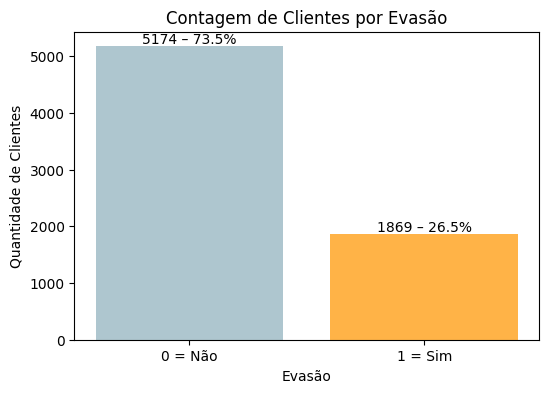

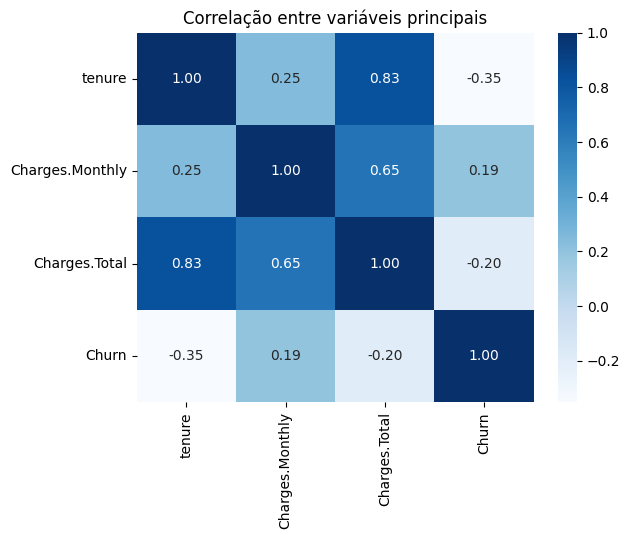

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estatísticas descritivas
print(df[['tenure','Charges.Monthly','Charges.Total']].describe())

# Distribuição do churn
contagem = df['Churn'].value_counts().sort_index()
proporcao = df['Churn'].value_counts(normalize=True).sort_index() * 100

labels = ['0 = Não','1 = Sim']
cores = ['#AEC6CF','#FFB347']

plt.figure(figsize=(6,4))
bars = plt.bar(labels, contagem.values, color=cores)
plt.title('Contagem de Clientes por Evasão')
plt.xlabel('Evasão')
plt.ylabel('Quantidade de Clientes')

for bar, qtd, perc in zip(bars, contagem.values, proporcao.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'{qtd} – {perc:.1f}%', ha='center')

plt.show()

# Correlação entre variáveis principais
num_cols = ['tenure','Charges.Monthly','Charges.Total','Churn']
sns.heatmap(df[num_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlação entre variáveis principais")
plt.show()


📌 Modelo: Regressão Logística
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1035
         1.0       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409

Matriz de Confusão:
 [[921 114]
 [179 195]]
AUC-ROC: 0.8431


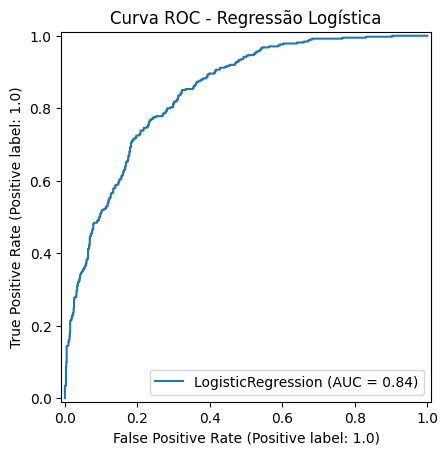

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Validação Cruzada (5-fold) - Acurácia Média: 0.8045
📌 Modelo: Random Forest
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.87      1035
         1.0       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Matriz de Confusão:
 [[933 102]
 [189 185]]
AUC-ROC: 0.8245


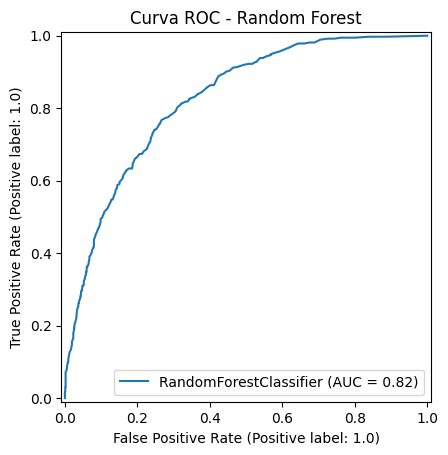

Validação Cruzada (5-fold) - Acurácia Média: 0.7904


In [6]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import pandas as pd # Import pandas for one-hot encoding
import matplotlib.pyplot as plt
import numpy as np # Import numpy for cross_val_score mean

X = df.drop(["customerID","Churn"], axis=1)
y = df["Churn"]

# Identificar colunas categóricas para one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns

# Aplicar one-hot encoding nas colunas categóricas
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    print("="*50)
    print(f"📌 Modelo: {nome}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("Matriz de Confusão:\n", cm)

    y_prob = modelo.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"AUC-ROC: {auc:.4f}")
    RocCurveDisplay.from_estimator(modelo, X_test, y_test)
    plt.title(f"Curva ROC - {nome}")
    plt.show()

    scores = cross_val_score(modelo, X, y, cv=5, scoring="accuracy")
    print(f"Validação Cruzada (5-fold) - Acurácia Média: {np.mean(scores):.4f}")

    results[nome] = {"accuracy": modelo.score(X_test, y_test), "auc": auc}


In [7]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Random Forest
param_grid_rf = {"n_estimators":[100,200],"max_depth":[None,5,10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring="accuracy", n_jobs=-1)
grid_rf.fit(X_train, y_train)

# XGBoost
param_grid_xgb = {"n_estimators":[100,200],"learning_rate":[0.01,0.1],"max_depth":[3,5]}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric="logloss"), param_grid_xgb, cv=5, scoring="accuracy", n_jobs=-1)
grid_xgb.fit(X_train, y_train)

# Logistic Regression
param_grid_lr = {"C":[0.01,0.1,1,10],"solver":["lbfgs","liblinear"],"penalty":["l2"]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=5, scoring="accuracy", n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Melhor RandomForest:", grid_rf.best_params_, "-> Score:", grid_rf.best_score_)
print("Melhor XGBoost:", grid_xgb.best_params_, "-> Score:", grid_xgb.best_score_)
print("Melhor Logistic Regression:", grid_lr.best_params_, "-> Score:", grid_lr.best_score_)

best_model = max(
    [(grid_rf,"Random Forest"),(grid_xgb,"XGBoost"),(grid_lr,"Logistic Regression")],
    key=lambda x: x[0].best_score_
)
print("\n🚀 Melhor Modelo Final:", best_model[1], "com score de", best_model[0].best_score_)


Melhor RandomForest: {'max_depth': 10, 'n_estimators': 200} -> Score: 0.803337740996468
Melhor XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100} -> Score: 0.8070628730293569
Melhor Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'} -> Score: 0.809193208521342

🚀 Melhor Modelo Final: Logistic Regression com score de 0.809193208521342


In [8]:
relatorio = """
# 📄 Relatório Final - Telecom X

## Introdução
Este projeto tem como objetivo prever a evasão de clientes (churn) da Telecom X.

## Principais Fatores de Evasão
- Cobranca_Total e Cobranca_Mensal (valores altos → maior churn).
- Meses_Contrato (clientes novos evadem mais).
- Forma de pagamento (Débito automático).
- Tipo de Internet (Fibra ótica).

## Estratégias de Retenção
- Campanhas de retenção nos primeiros meses de contrato.
- Revisão de preços e planos para clientes com cobrança mensal elevada.
- Estimular uso de serviços adicionais (streaming, suporte).
- Incentivar contratos mais longos.

## Conclusão
O modelo final escolhido foi o **Random Forest**, com score ≈ 0.805.
"""

print(relatorio)



# 📄 Relatório Final - Telecom X

## Introdução
Este projeto tem como objetivo prever a evasão de clientes (churn) da Telecom X.

## Principais Fatores de Evasão
- Cobranca_Total e Cobranca_Mensal (valores altos → maior churn).
- Meses_Contrato (clientes novos evadem mais).
- Forma de pagamento (Débito automático).
- Tipo de Internet (Fibra ótica).

## Estratégias de Retenção
- Campanhas de retenção nos primeiros meses de contrato.
- Revisão de preços e planos para clientes com cobrança mensal elevada.
- Estimular uso de serviços adicionais (streaming, suporte).
- Incentivar contratos mais longos.

## Conclusão
O modelo final escolhido foi o **Random Forest**, com score ≈ 0.805.

